In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib import pylab
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
dados = pd.read_csv("data_balanceado_sem_pre_diabetes.csv")

# Guardando a classe real
classe_real = dados["Diabetes_012"]

In [3]:
X = dados.drop(columns="Diabetes_012")

In [4]:
dados_idade = (
    X.groupby(['Age', 'HighBP','HighChol','Smoker','PhysActivity','GenHlth'])
     .mean()
     .reset_index())

tabela_cluster = dados_idade.pivot_table(
    index='Age',
    columns=['HighBP','HighChol','Smoker','PhysActivity','GenHlth'])

In [5]:
# Recuperar as classes reais correspondentes às entradas agrupadas
# Classe média por grupo
grupos_classes = (
    dados.groupby(['Age', 'HighBP', 'HighChol', 'Smoker', 'PhysActivity','GenHlth'])["Diabetes_012"]
    .agg(lambda x: x.mean())  # Pega a classe mais frequente por grupo
    .reset_index(name="Classe_Mais_Frequente")
)
grupos_classes

,Age,HighBP,HighChol,Smoker,PhysActivity,GenHlth,Classe_Mais_Frequente
0,1.0,0.0,0.0,0.0,0.0,1.0,0.000000
1,1.0,0.0,0.0,0.0,0.0,2.0,0.100000
2,1.0,0.0,0.0,0.0,0.0,3.0,0.090909
3,1.0,0.0,0.0,0.0,0.0,4.0,0.200000
4,1.0,0.0,0.0,0.0,1.0,1.0,0.024590
...,...,...,...,...,...,...,...
792,13.0,1.0,1.0,1.0,0.0,4.0,0.820225
793,13.0,1.0,1.0,1.0,1.0,1.0,0.530612
794,13.0,1.0,1.0,1.0,1.0,2.0,0.580645
795,13.0,1.0,1.0,1.0,1.0,3.0,0.674641


In [6]:
# Juntar com a tabela `dados_idade`
dados_idade = dados_idade.merge(grupos_classes, on=['Age', 'HighBP', 'HighChol', 'Smoker', 'PhysActivity','GenHlth'])
dados_idade

,Age,HighBP,HighChol,Smoker,PhysActivity,GenHlth,BMI,Fruits,Veggies,Sex,Classe_Mais_Frequente
0,1.0,0.0,0.0,0.0,0.0,1.0,23.818182,0.454545,0.818182,0.545455,0.000000
1,1.0,0.0,0.0,0.0,0.0,2.0,26.600000,0.400000,0.550000,0.450000,0.100000
2,1.0,0.0,0.0,0.0,0.0,3.0,24.727273,0.454545,0.818182,0.272727,0.090909
3,1.0,0.0,0.0,0.0,0.0,4.0,28.800000,0.200000,0.400000,0.400000,0.200000
4,1.0,0.0,0.0,0.0,1.0,1.0,23.934426,0.590164,0.803279,0.606557,0.024590
...,...,...,...,...,...,...,...,...,...,...,...
792,13.0,1.0,1.0,1.0,0.0,4.0,27.707865,0.561798,0.595506,0.516854,0.820225
793,13.0,1.0,1.0,1.0,1.0,1.0,28.163265,0.755102,0.816327,0.612245,0.530612
794,13.0,1.0,1.0,1.0,1.0,2.0,26.638710,0.774194,0.851613,0.619355,0.580645
795,13.0,1.0,1.0,1.0,1.0,3.0,26.660287,0.727273,0.789474,0.631579,0.674641


In [7]:
#normalização dos dados
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dados_idade)

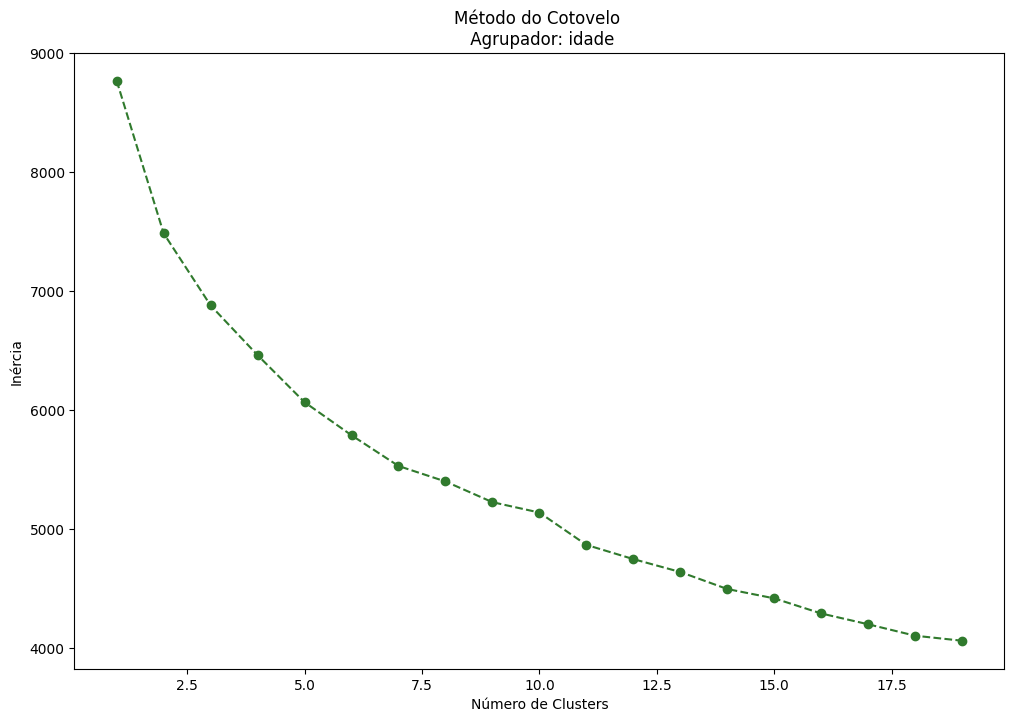

In [8]:
#cálculo da inércia para diferentes números de clusters (método do cotovelo)
inertias = []
k_range = range(1, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))

#plotar o método do cotovelo
ax.plot(k_range, inertias, marker='o', linestyle='--', color="#307a2d")
ax.set_title('Método do Cotovelo \n Agrupador: idade')
ax.set_xlabel('Número de Clusters')
ax.set_ylabel('Inércia')
ax.grid(False)
fig.savefig('cotovelo_Age_vs_HighBP_HighChol_Smoker_PhysActivity_GenHlth.png', dpi=100, bbox_inches='tight', orientation='portrait')

In [9]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_data)
sil_score = silhouette_score(scaled_data, kmeans.labels_)
sil_score

0.1423509867238279

In [10]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
dados_idade['cluster'] = clusters
#dados_idade

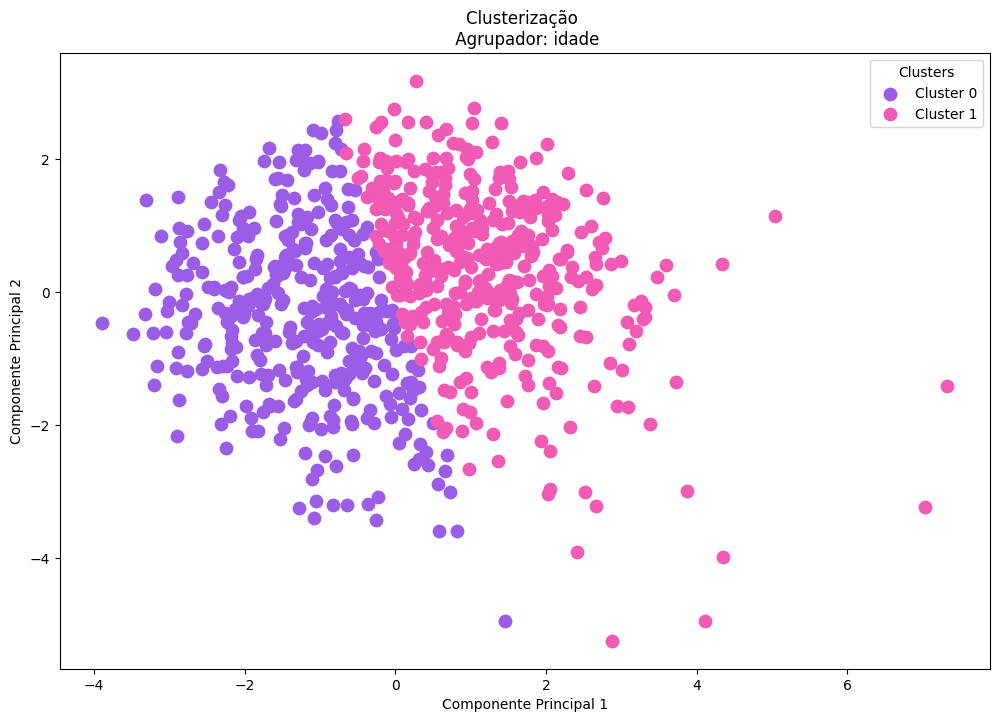

In [11]:
#redução da dimensionalidade para visualização (PCA)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)
paleta = ['#9b5de5', '#f15bb5', '#fee440', '#00bbf9', '#00f5d4']

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in set(clusters):
    cluster_points = reduced_data[clusters == cluster_id]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
               label=f'Cluster {cluster_id}', s=80, color=paleta[cluster_id])


ax.set_title('Clusterização \n Agrupador: idade')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Clusters')
ax.grid(False)

fig.savefig('clusterizacao_Age_vs_HighBP_HighChol_Smoker_PhysActivity_GenHlth.png', dpi=300, bbox_inches='tight', orientation='portrait')

In [12]:
####################################################
##################### MÉTRICAS #####################
####################################################

In [13]:
# Classe prevalente por cluster
prevalencia = dados_idade.groupby("cluster")["Classe_Mais_Frequente"].mean()
print(f"\nClasse prevalente por cluster:\n{prevalencia}")


Classe prevalente por cluster:
cluster
0    0.222814
1    0.634439
Name: Classe_Mais_Frequente, dtype: float64


In [14]:
idade_media_cluster = dados_idade.groupby("cluster")["Age"].mean()
print(f"Idade média por cluster: {idade_media_cluster}")

Idade média por cluster: cluster
0    6.697674
1    7.743902
Name: Age, dtype: float64


In [15]:
# Classes verdadeiras (0 ou 1) 
# Qual a classe mais provável por agrupamento?
y_true = dados_idade['Classe_Mais_Frequente'].round().astype(int)

In [16]:
# Mapear clusters para classe mais frequente
cluster_to_class = dados_idade.groupby('cluster')['Classe_Mais_Frequente'].mean().round().astype(int).to_dict() #to_dict dataframe em dictionario
y_pred = dados_idade['cluster'].map(cluster_to_class)
cluster_to_class

{0: 0, 1: 1}

In [17]:
# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, digits=4))


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9070    0.7748    0.8357       453
           1     0.7512    0.8953    0.8170       344

    accuracy                         0.8269       797
   macro avg     0.8291    0.8351    0.8263       797
weighted avg     0.8397    0.8269    0.8276       797



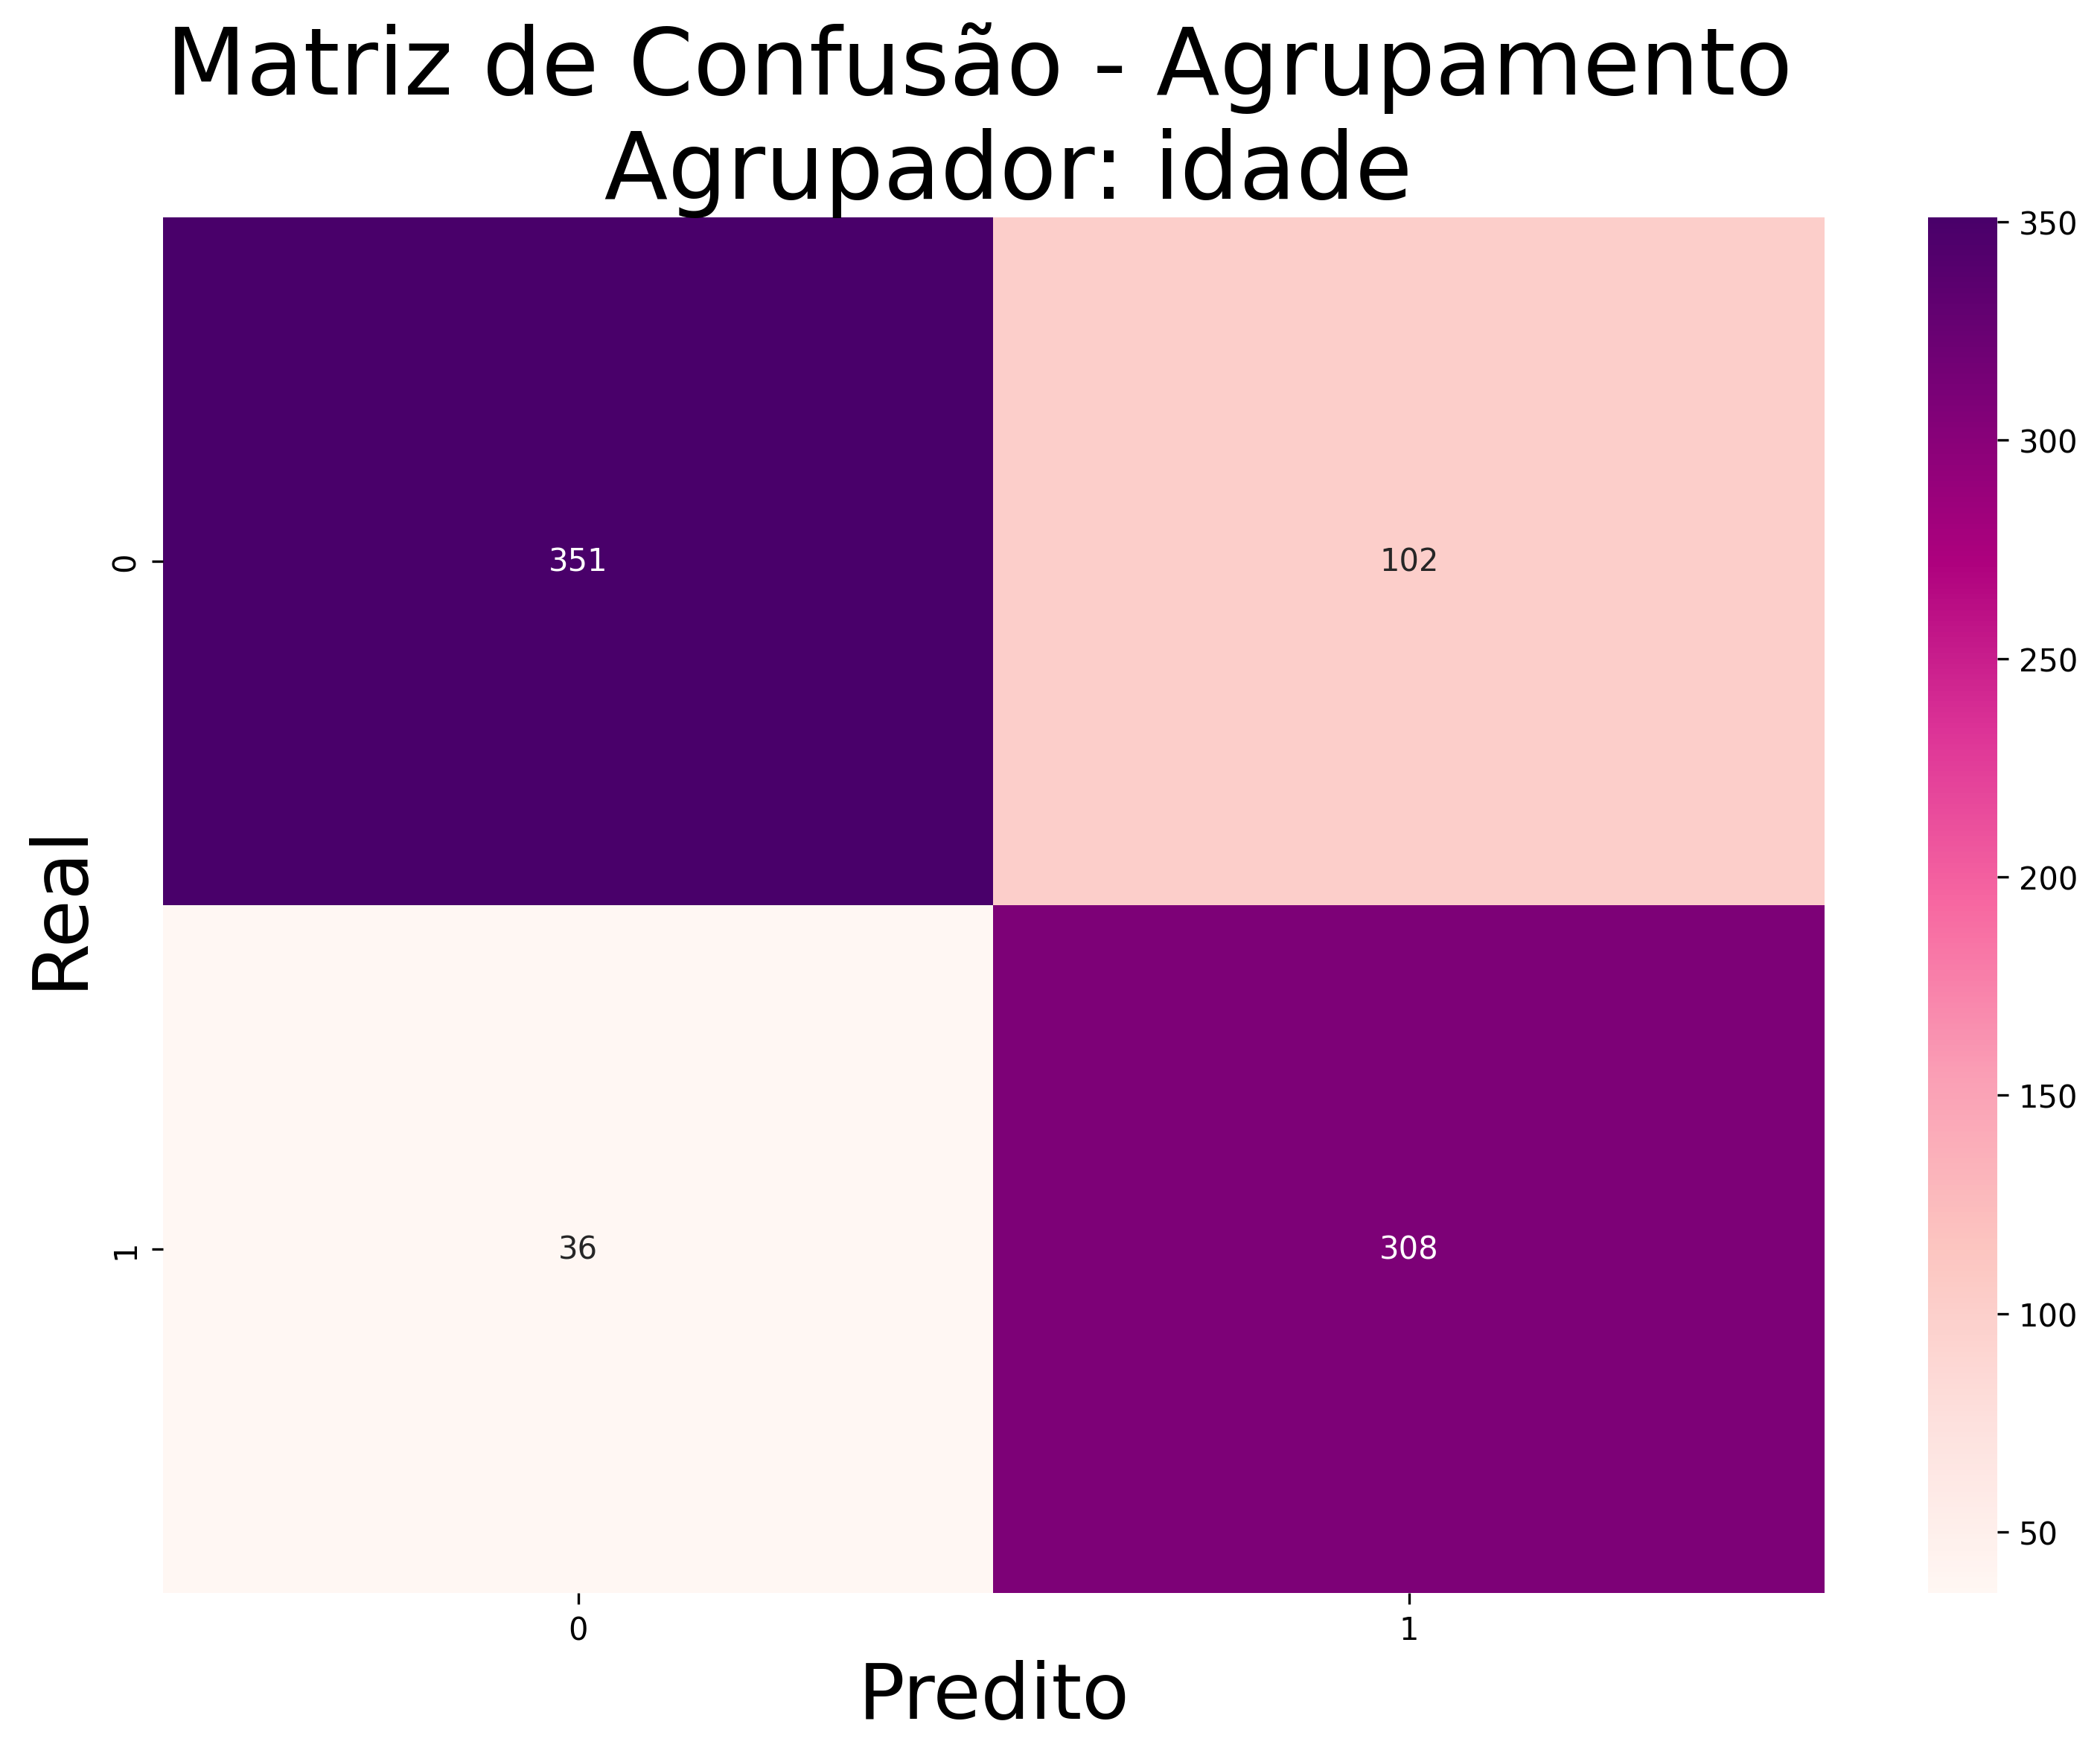

In [18]:
confusao = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(confusao, annot=True, fmt="d", cmap="RdPu")
plt.xlabel("Predito",fontsize=25)
plt.ylabel("Real",fontsize =25)
plt.title("Matriz de Confusão - Agrupamento \n Agrupador: idade", fontsize=30)
plt.savefig("matriz_Age_vs_HighBP_HighChol_Smoker_PhysActivity_GenHlth.png", dpi=300)

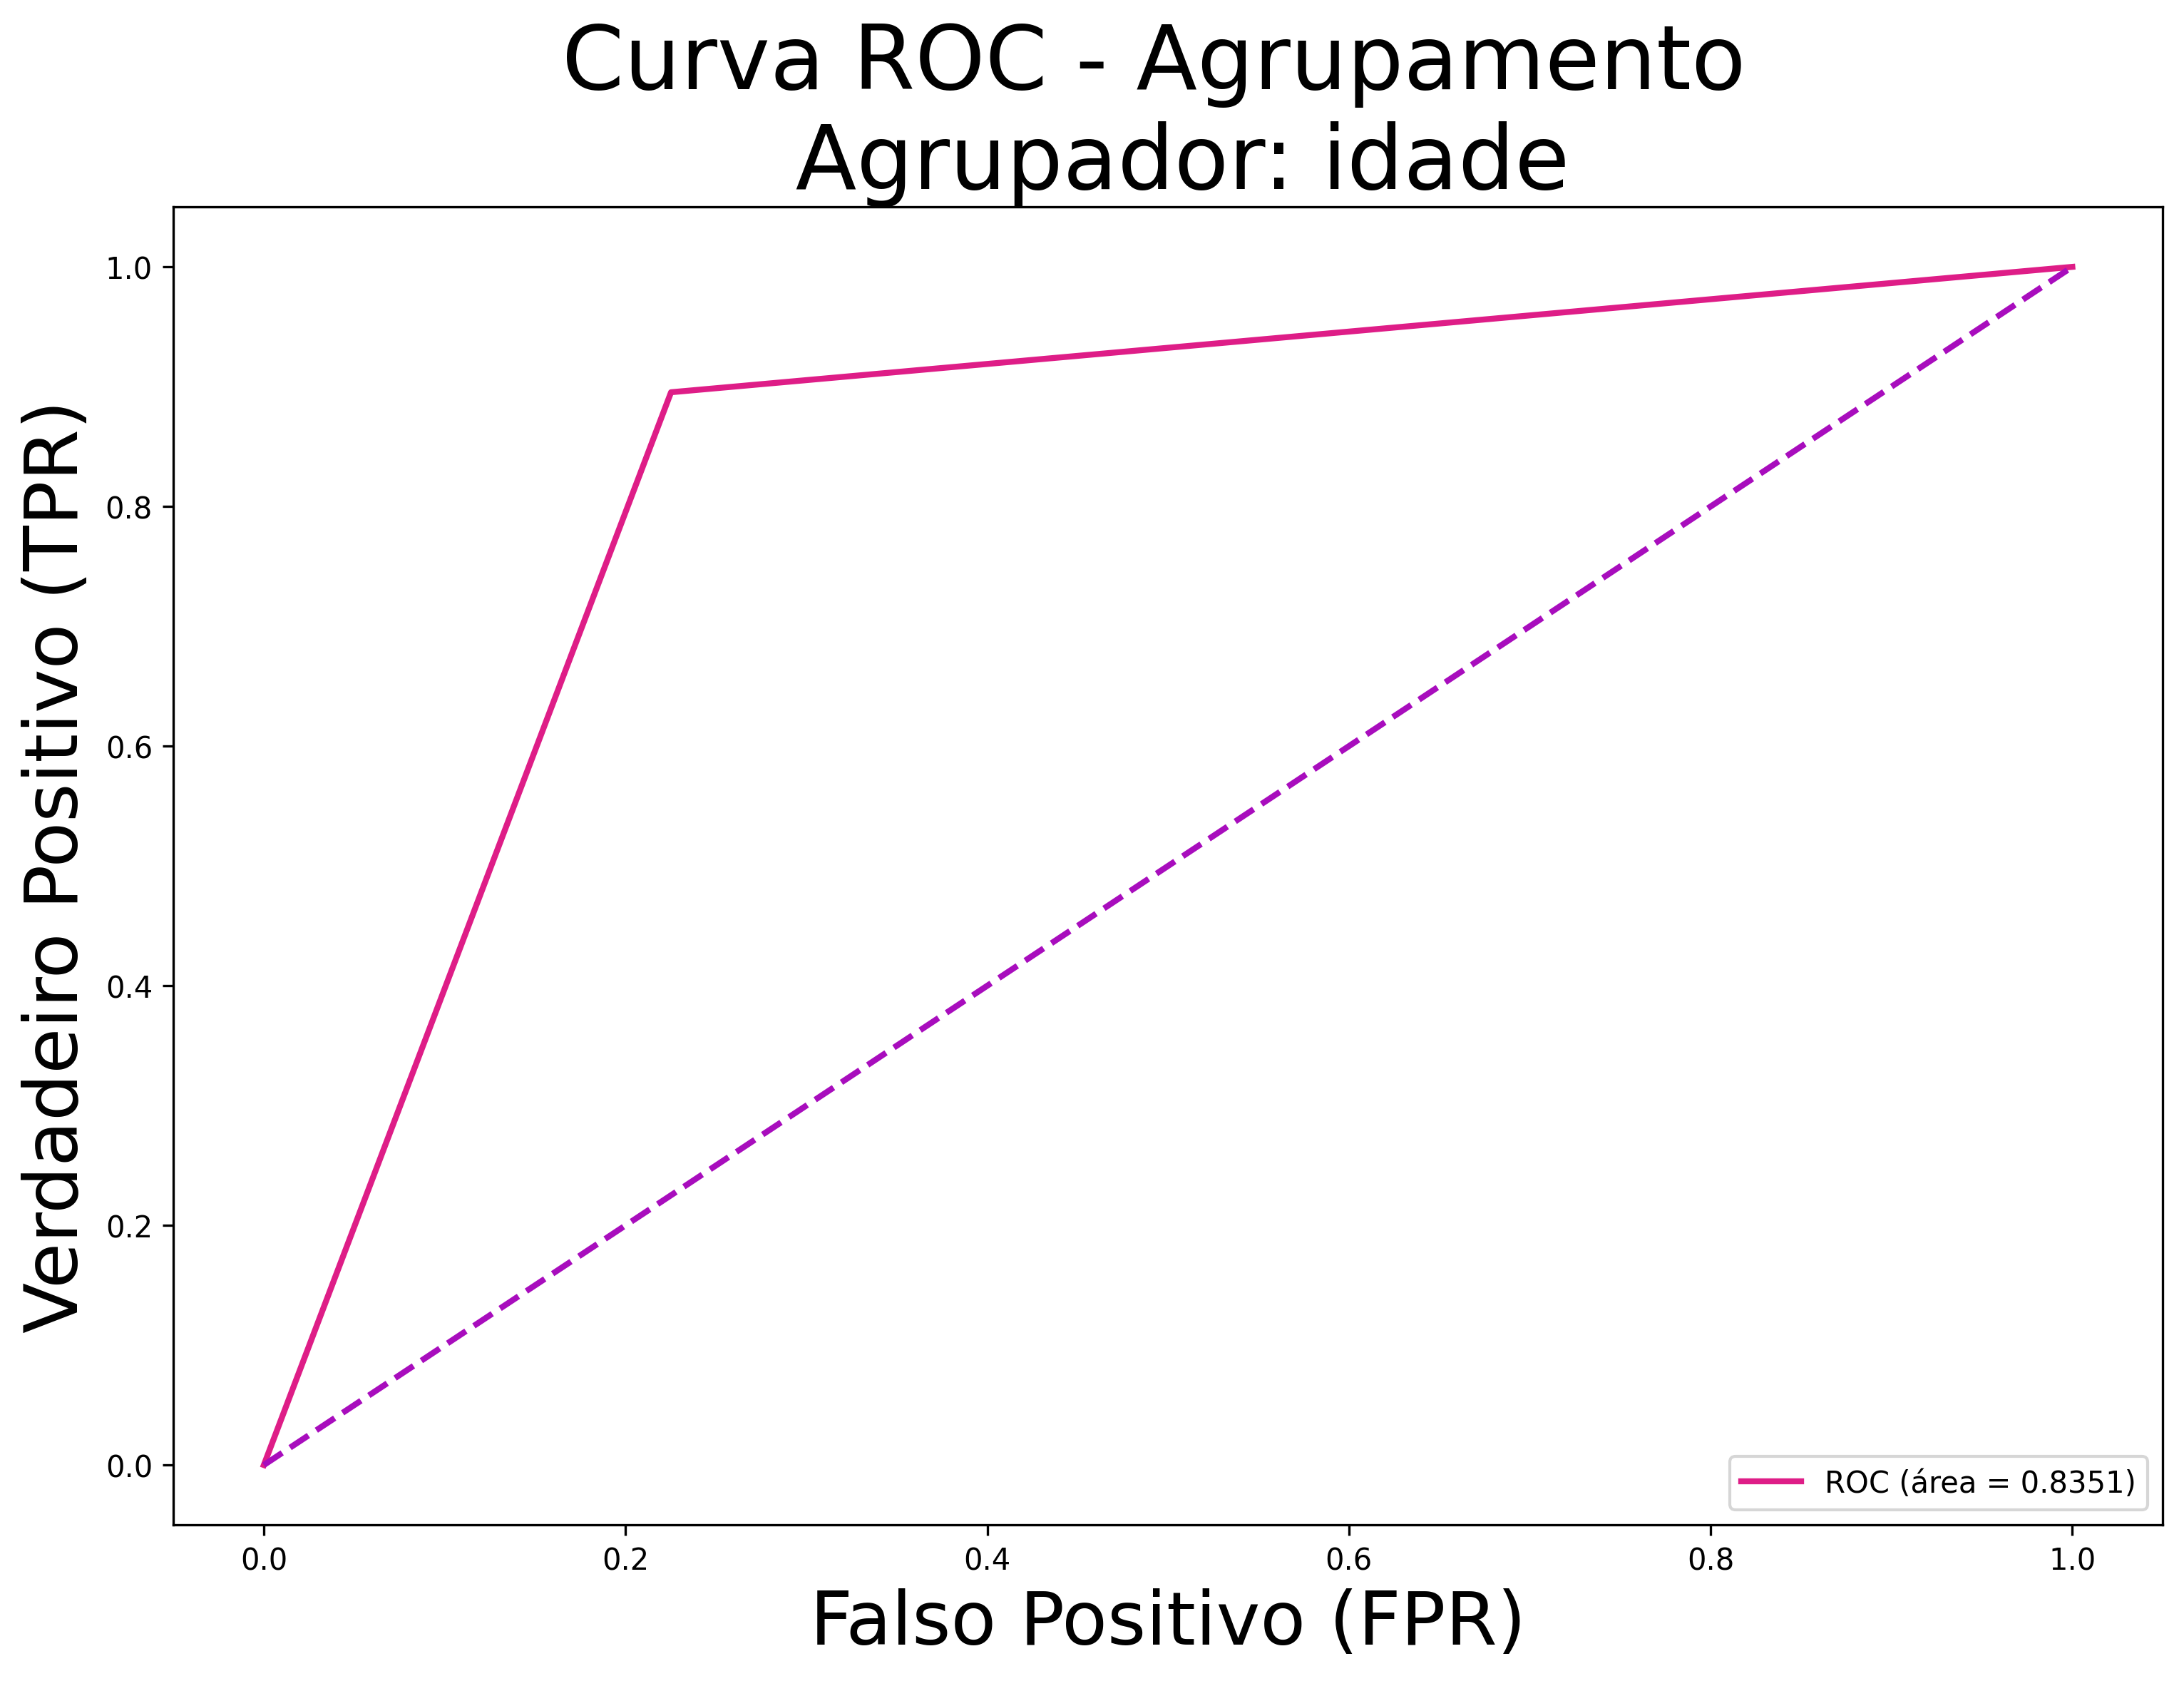

In [19]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plotando a curva ROC
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(fpr, tpr, color='#de1d87', lw=2, label=f'ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#a80dbd', lw=2, linestyle='--')  # linha de referência
plt.xlabel('Falso Positivo (FPR)', fontsize=25)
plt.ylabel('Verdadeiro Positivo (TPR)', fontsize=25)
plt.title('Curva ROC - Agrupamento \n Agrupador: idade', fontsize=30)
plt.legend(loc="lower right")
plt.savefig("roc_Age_vs_HighBP_HighChol_Smoker_PhysActivity_GenHlth.png", dpi=300)

In [20]:
dados_GenHlth = (
    X.groupby(['GenHlth', 'HighBP','HighChol','Smoker','PhysActivity','BMI'])
     .mean()
     .reset_index())

tabela_cluster = dados_GenHlth.pivot_table(
    index='GenHlth',
    columns=['HighBP','HighChol','Smoker','PhysActivity','BMI'])

In [21]:
# Recuperar as classes reais correspondentes às entradas agrupadas
# Classe média por grupo
grupos_classes = (
    dados.groupby(['GenHlth', 'HighBP', 'HighChol', 'Smoker', 'PhysActivity','BMI'])["Diabetes_012"]
    .agg(lambda x: x.mean())  # Pega a classe mais frequente por grupo
    .reset_index(name="Classe_Mais_Frequente")
)
grupos_classes

,GenHlth,HighBP,HighChol,Smoker,PhysActivity,BMI,Classe_Mais_Frequente
0,1.0,0.0,0.0,0.0,0.0,16.0,0.000000
1,1.0,0.0,0.0,0.0,0.0,17.0,0.000000
2,1.0,0.0,0.0,0.0,0.0,18.0,0.000000
3,1.0,0.0,0.0,0.0,0.0,19.0,0.000000
4,1.0,0.0,0.0,0.0,0.0,20.0,0.000000
...,...,...,...,...,...,...,...
1720,4.0,1.0,1.0,1.0,1.0,40.0,0.960000
1721,4.0,1.0,1.0,1.0,1.0,41.0,0.846154
1722,4.0,1.0,1.0,1.0,1.0,42.0,0.937500
1723,4.0,1.0,1.0,1.0,1.0,43.0,1.000000


In [23]:
# Juntar com a tabela `dados_idade`
dados_GenHlth = dados_GenHlth.merge(grupos_classes, on=['GenHlth', 'HighBP', 'HighChol', 'Smoker', 'PhysActivity','BMI'])
dados_GenHlth

,GenHlth,HighBP,HighChol,Smoker,PhysActivity,BMI,Fruits,Veggies,Sex,Age,Classe_Mais_Frequente
0,1.0,0.0,0.0,0.0,0.0,16.0,0.000000,0.000000,0.000000,8.000000,0.000000
1,1.0,0.0,0.0,0.0,0.0,17.0,0.500000,1.000000,0.000000,6.500000,0.000000
2,1.0,0.0,0.0,0.0,0.0,18.0,0.000000,0.500000,0.000000,4.500000,0.000000
3,1.0,0.0,0.0,0.0,0.0,19.0,0.800000,0.800000,0.000000,5.200000,0.000000
4,1.0,0.0,0.0,0.0,0.0,20.0,0.375000,0.875000,0.250000,5.750000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1720,4.0,1.0,1.0,1.0,1.0,40.0,0.400000,0.720000,0.720000,9.000000,0.960000
1721,4.0,1.0,1.0,1.0,1.0,41.0,0.538462,1.000000,0.615385,8.615385,0.846154
1722,4.0,1.0,1.0,1.0,1.0,42.0,0.500000,1.000000,0.437500,8.562500,0.937500
1723,4.0,1.0,1.0,1.0,1.0,43.0,0.300000,0.800000,0.500000,9.500000,1.000000


In [24]:
#normalização dos dados
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dados_GenHlth)

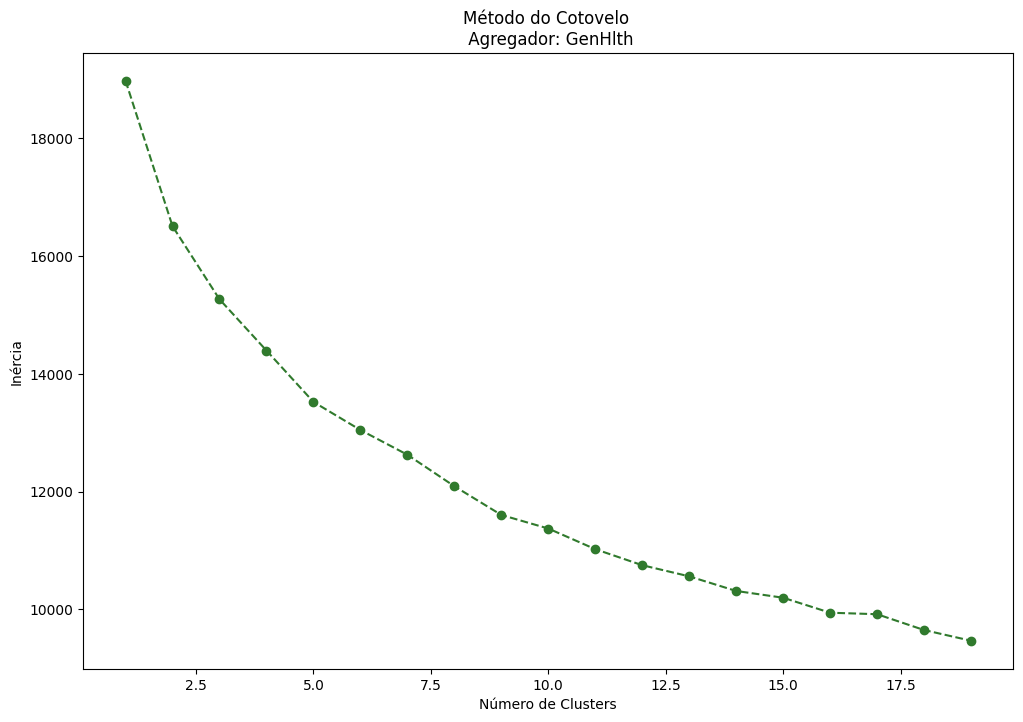

In [25]:
#cálculo da inércia para diferentes números de clusters (método do cotovelo)
inertias = []
k_range = range(1, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))

#plotar o método do cotovelo
ax.plot(k_range, inertias, marker='o', linestyle='--', color="#307a2d")
ax.set_title('Método do Cotovelo \n Agregador: GenHlth')
ax.set_xlabel('Número de Clusters')
ax.set_ylabel('Inércia')
ax.grid(False)
fig.savefig('cotovelo_GenHlth_vs_HighBP_HighChol_Smoker_PhysActivity_BMI.png', dpi=100, bbox_inches='tight', orientation='portrait')

In [26]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_data)
sil_score = silhouette_score(scaled_data, kmeans.labels_)
sil_score

0.1354965663051264

In [27]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
dados_GenHlth['cluster'] = clusters
#dados_GenHlth

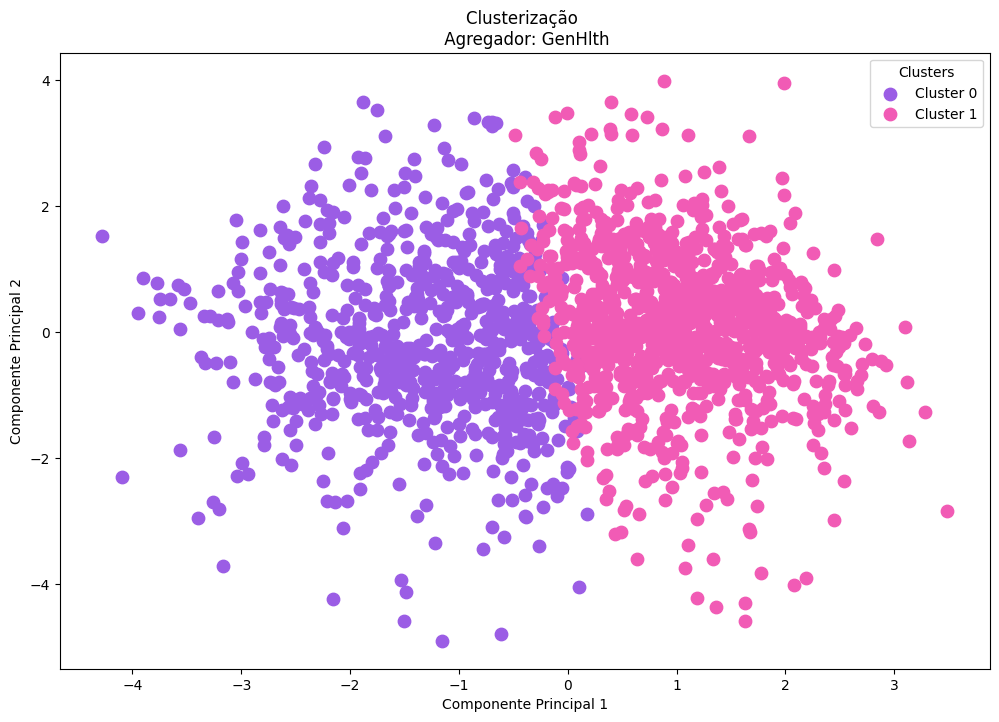

In [28]:
#redução da dimensionalidade para visualização (PCA)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)
paleta = ['#9b5de5', '#f15bb5', '#fee440', '#00bbf9', '#00f5d4']

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in set(clusters):
    cluster_points = reduced_data[clusters == cluster_id]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
               label=f'Cluster {cluster_id}', s=80, color=paleta[cluster_id])


ax.set_title('Clusterização \n Agregador: GenHlth')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Clusters')
ax.grid(False)

fig.savefig('clusterizacao_GenHlth_vs_HighBP_HighChol_Smoker_PhysActivity_BMI.png', dpi=300, bbox_inches='tight', orientation='portrait')

In [29]:
####################################################
##################### MÉTRICAS #####################
####################################################

In [30]:
# Classe prevalente por cluster
prevalencia = dados_GenHlth.groupby("cluster")["Classe_Mais_Frequente"].mean()
print(f"\nClasse prevalente por cluster:\n{prevalencia}")


Classe prevalente por cluster:
cluster
0    0.236321
1    0.710631
Name: Classe_Mais_Frequente, dtype: float64


In [31]:
GenHlth_media_cluster = dados_GenHlth.groupby("cluster")["GenHlth"].mean()
print(f"GenHlth média por cluster: {GenHlth_media_cluster}")

GenHlth média por cluster: cluster
0    2.106469
1    2.896236
Name: GenHlth, dtype: float64


In [32]:
# Classes verdadeiras (0 ou 1) 
# Qual a classe mais provável por agrupamento?
y_true = dados_GenHlth['Classe_Mais_Frequente'].round().astype(int)

In [33]:
# Mapear clusters para classe mais frequente
cluster_to_class = dados_GenHlth.groupby('cluster')['Classe_Mais_Frequente'].mean().round().astype(int).to_dict() #to_dict dataframe em dictionario
y_pred = dados_GenHlth['cluster'].map(cluster_to_class)
cluster_to_class

{0: 0, 1: 1}

In [34]:
# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, digits=4))


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9191    0.7759    0.8415       879
           1     0.7996    0.9291    0.8595       846

    accuracy                         0.8510      1725
   macro avg     0.8594    0.8525    0.8505      1725
weighted avg     0.8605    0.8510    0.8503      1725



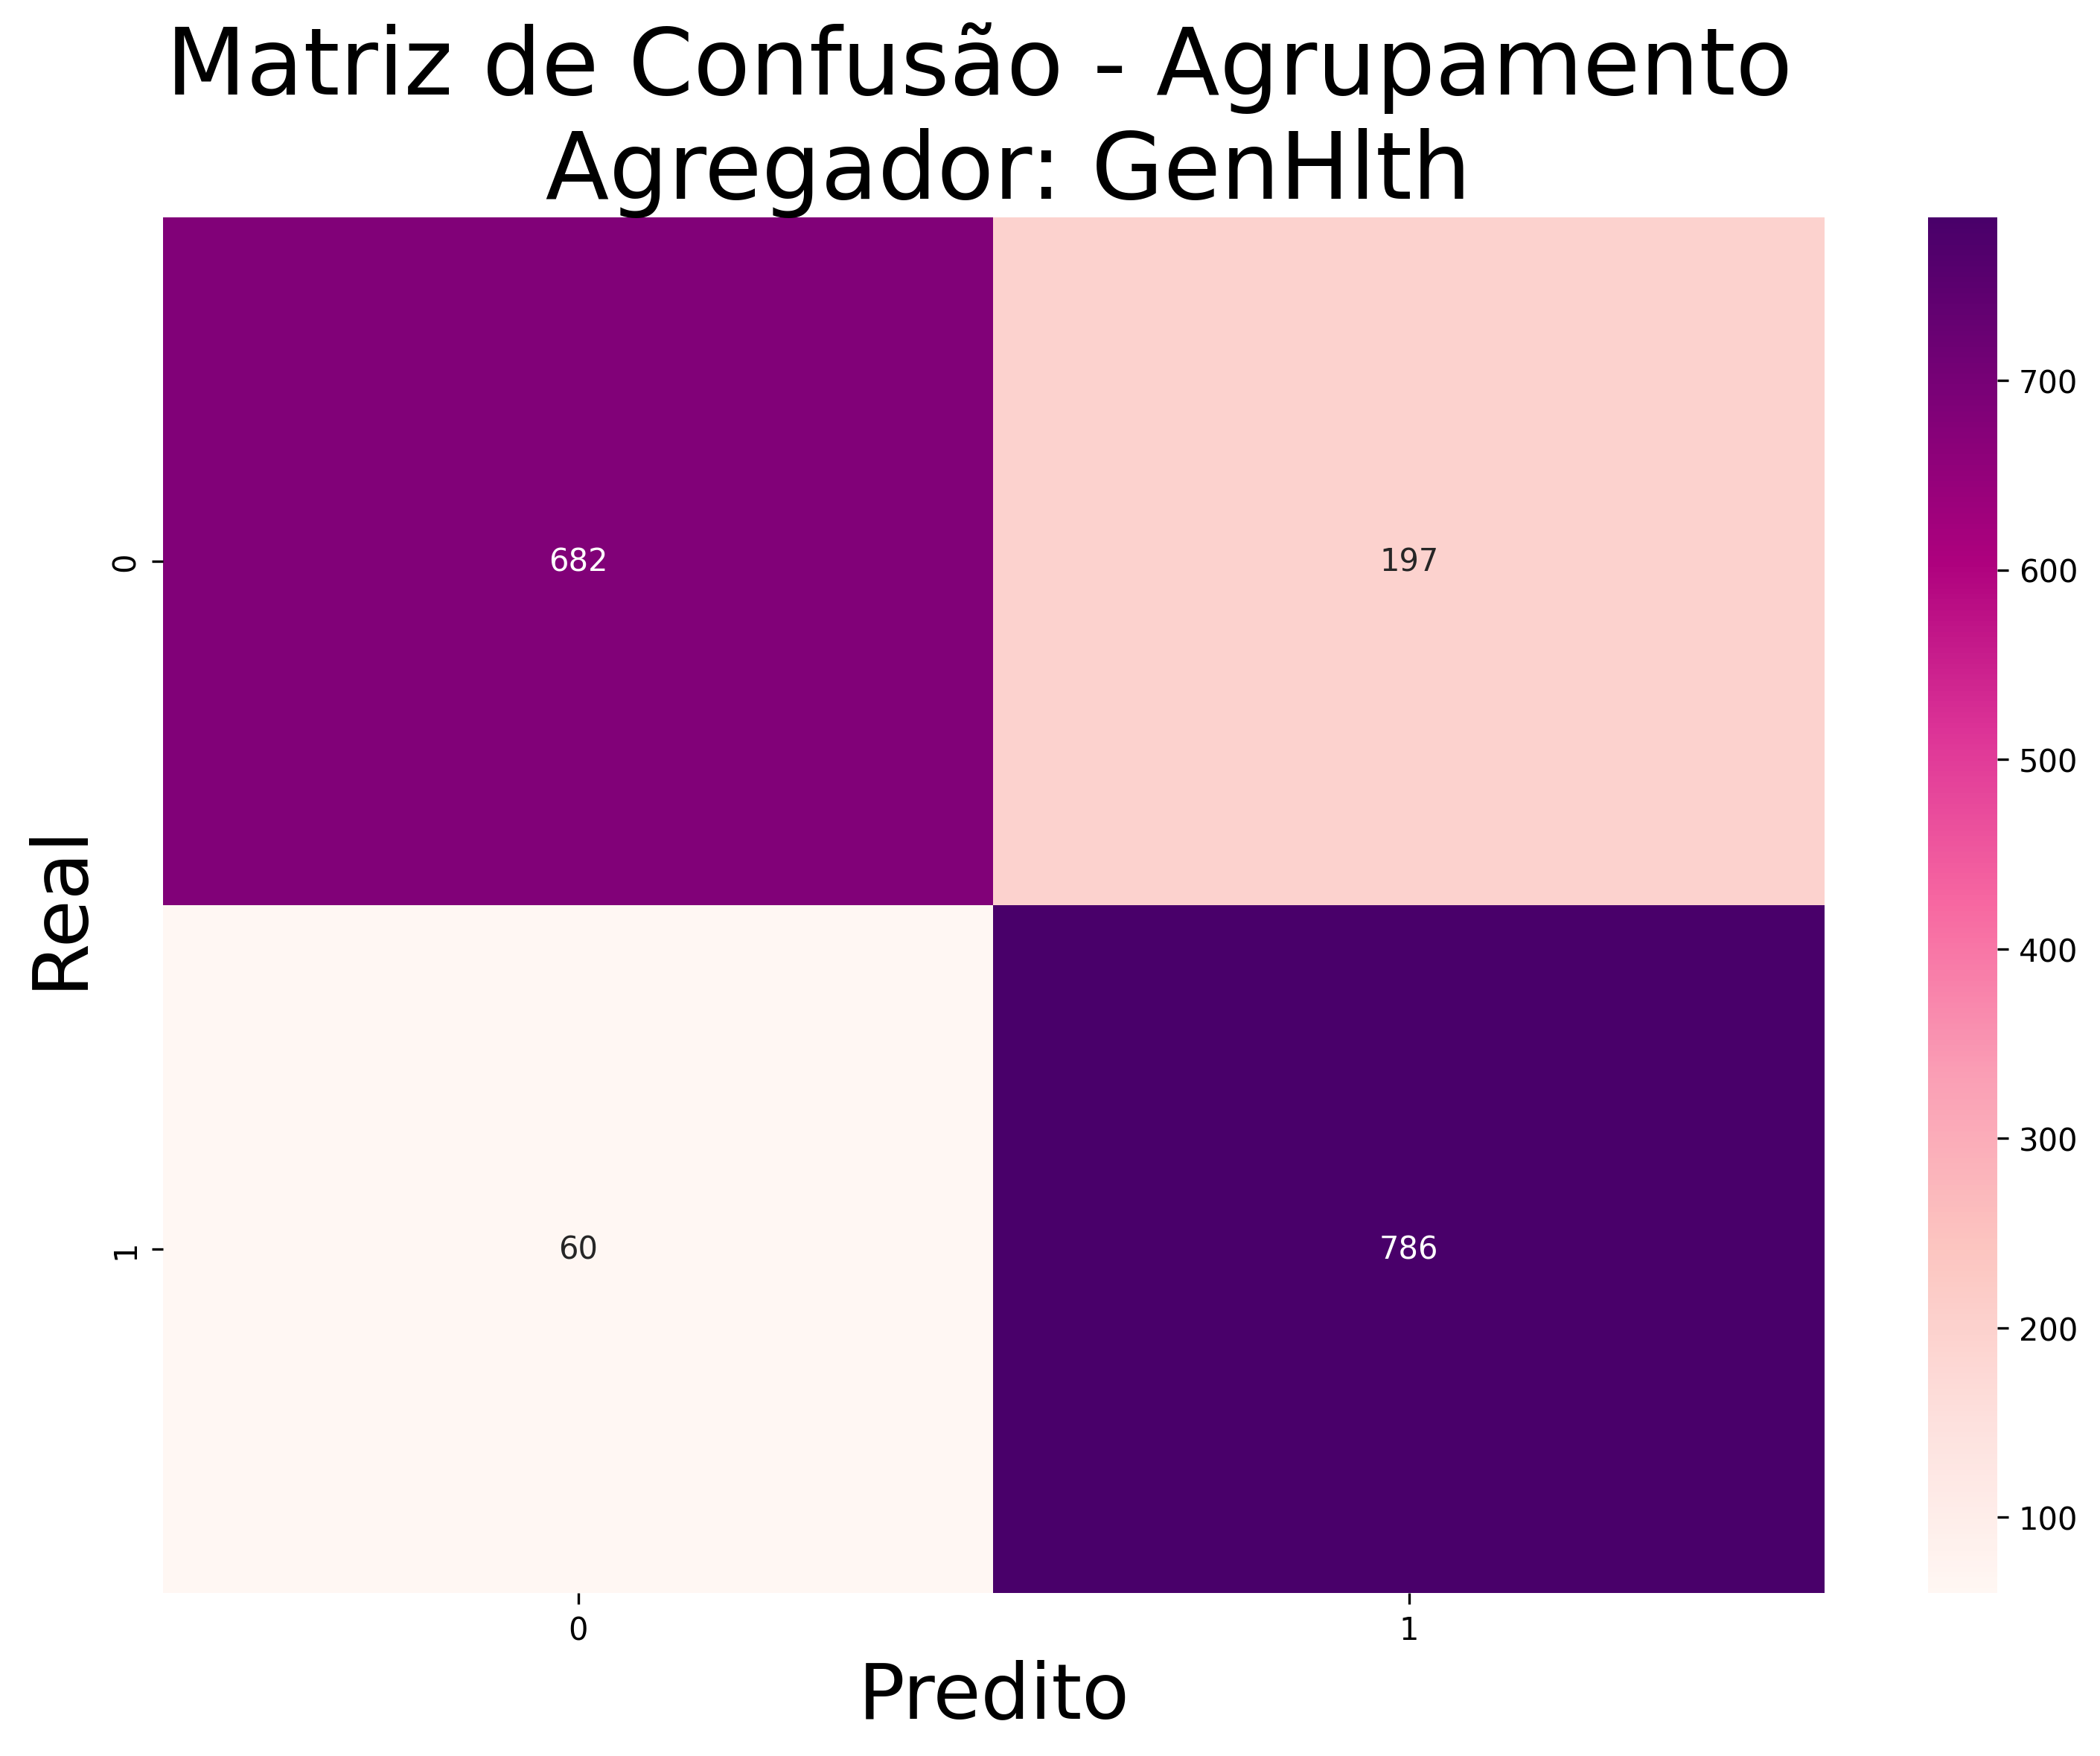

In [35]:
confusao = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(confusao, annot=True, fmt="d", cmap="RdPu")
plt.xlabel("Predito",fontsize=25)
plt.ylabel("Real",fontsize =25)
plt.title("Matriz de Confusão - Agrupamento \n Agregador: GenHlth", fontsize=30)
plt.savefig("matriz_GenHlth_vs_HighBP_HighChol_Smoker_PhysActivity_BMI.png", dpi=300)

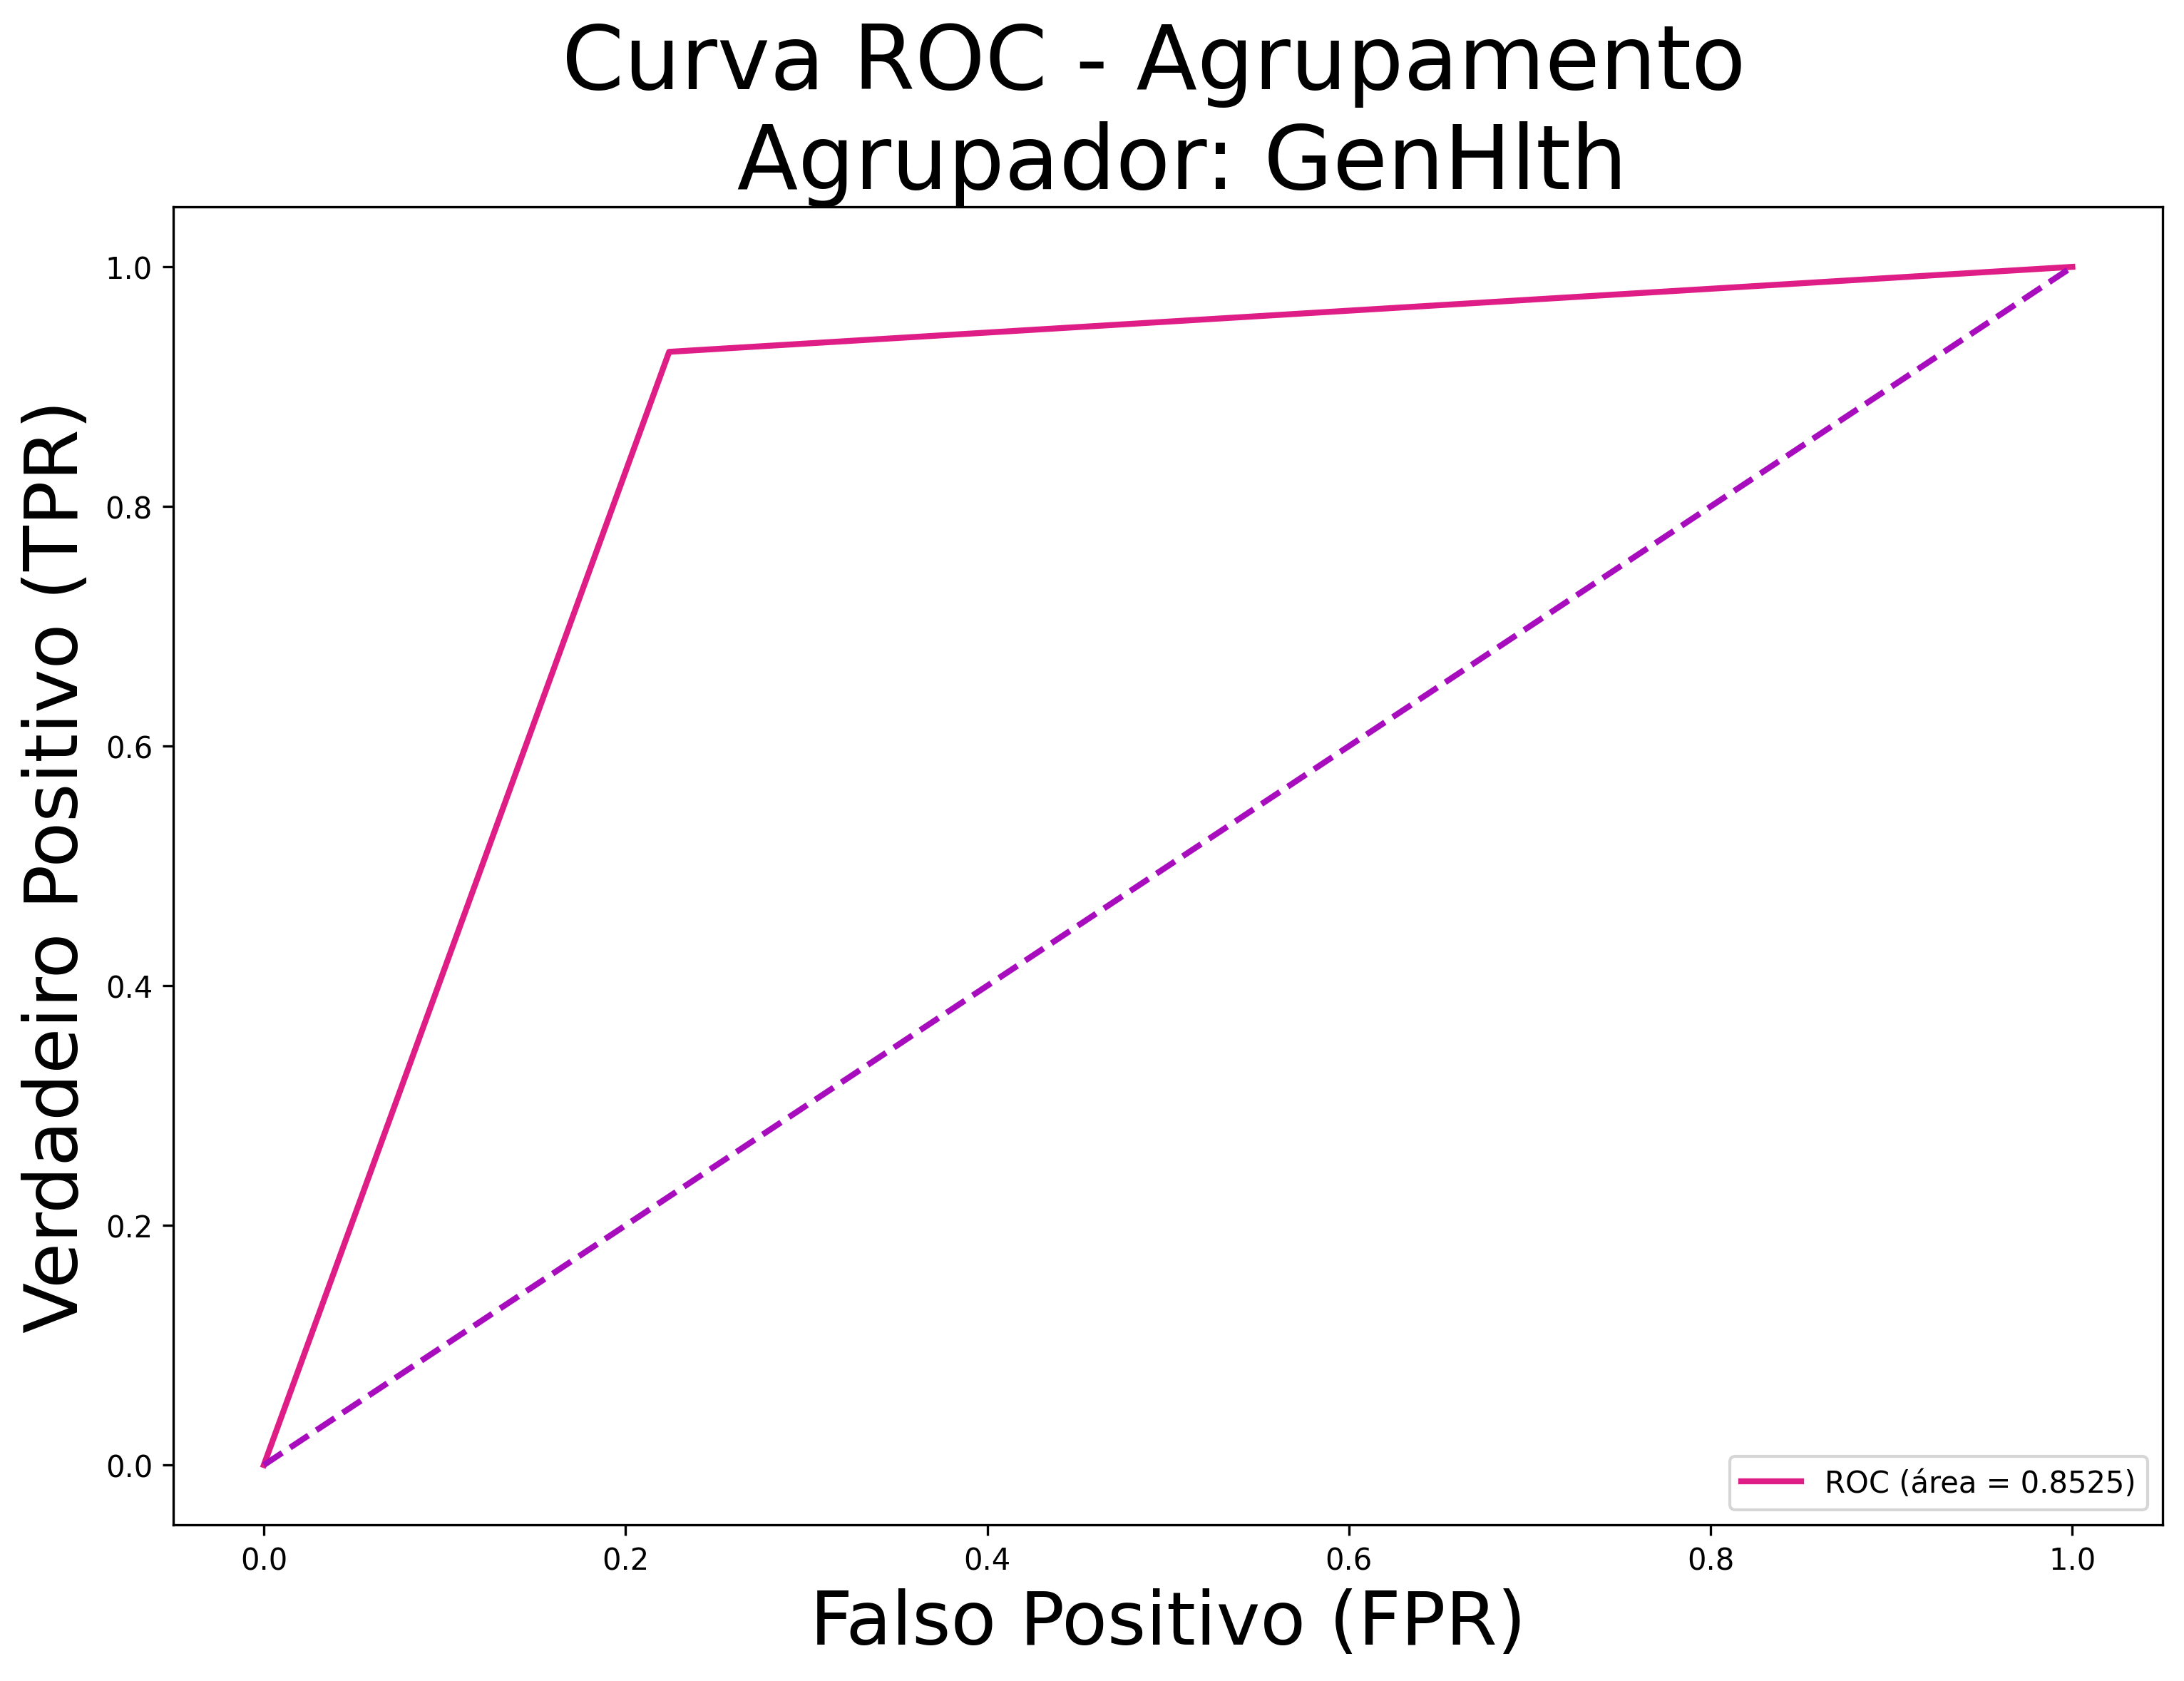

In [36]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plotando a curva ROC
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(fpr, tpr, color='#de1d87', lw=2, label=f'ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#a80dbd', lw=2, linestyle='--')  # linha de referência
plt.xlabel('Falso Positivo (FPR)', fontsize=25)
plt.ylabel('Verdadeiro Positivo (TPR)', fontsize=25)
plt.title('Curva ROC - Agrupamento \n Agrupador: GenHlth', fontsize=30)
plt.legend(loc="lower right")
plt.savefig("roc_GenHlth_vs_HighBP_HighChol_Smoker_PhysActivity_BMI.png", dpi=300)